In [ ]:
"""
============================================================
 Verificação visual de MÁSCARAS SEMÂNTICAS PNG (YOLO26 sem)
============================================================
Lê o dataset no formato semântico PNG:

    dataset/
    images/{train,val,test}/*.png
    masks/{train,val,test}/*.png   (0=fundo, 1=cafe) 

Para cada amostra plota 3 painéis: imagem | máscara colorida |
overlay, com a % de cada classe. Detecta automaticamente:
  - valores inesperados na máscara (≠ 0/1/255)
  - tiles "_BG" que contenham café (negativo contaminado)
  - desbalanceamento café vs fundo

============================================================
"""

import random
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


# Valores do class-map
FUNDO, CAFE, IGNORE = 0, 1, 255

# Cores do overlay
COR_CAFE   = np.array([60, 220, 60], dtype=np.float32)    # verde
COR_IGNORE = np.array([220, 60, 60], dtype=np.float32)    # vermelho
ALPHA = 0.45


# ============================================================
# IO
# ============================================================
def carregar_imagem(img_path: Path) -> np.ndarray:
    return np.array(Image.open(img_path).convert("RGB"))

def carregar_mascara(mask_path: Path) -> np.ndarray:
    if not mask_path.exists():
        return None
    return np.array(Image.open(mask_path).convert("L"))

def amostrar_tiles(dataset_root: Path, split: str, n: int, rng: random.Random):
    img_dir = dataset_root / "images" / split
    msk_dir = dataset_root / "masks"  / split
    if not img_dir.exists():
        return []
    imagens = sorted(img_dir.glob("*.png"))
    if not imagens:
        return []
    n = min(n, len(imagens))
    escolhidas = rng.sample(imagens, n)
    return [(p, msk_dir / f"{p.stem}.png") for p in escolhidas]


# ============================================================
# ANÁLISE
# ============================================================
def estatisticas_mascara(mask: np.ndarray) -> dict:
    total = mask.size
    n_cafe   = int((mask == CAFE).sum())
    n_fundo  = int((mask == FUNDO).sum())
    n_ignore = int((mask == IGNORE).sum())
    valores_inesperados = sorted(set(np.unique(mask).tolist()) - {FUNDO, CAFE, IGNORE})
    n_valido = n_cafe + n_fundo
    return {
        "pct_cafe": 100 * n_cafe / total,
        "pct_fundo": 100 * n_fundo / total,
        "pct_ignore": 100 * n_ignore / total,
        # taxa de café DENTRO da área supervisionada (exclui ignore)
        "pct_cafe_valido": (100 * n_cafe / n_valido) if n_valido else 0.0,
        "valores_inesperados": valores_inesperados,
        "n_cafe": n_cafe,
    }


def construir_overlay(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    over = img.astype(np.float32)
    cafe = (mask == CAFE)
    ign  = (mask == IGNORE)
    over[cafe] = (1 - ALPHA) * over[cafe] + ALPHA * COR_CAFE
    over[ign]  = (1 - ALPHA) * over[ign]  + ALPHA * COR_IGNORE
    return over.clip(0, 255).astype(np.uint8)


def construir_mascara_colorida(mask: np.ndarray) -> np.ndarray:
    H, W = mask.shape
    out = np.zeros((H, W, 3), dtype=np.uint8)
    out[mask == FUNDO]  = (40, 40, 40)      # cinza escuro
    out[mask == CAFE]   = (60, 220, 60)     # verde
    out[mask == IGNORE] = (220, 60, 60)     # vermelho
    return out


# ============================================================
# PLOT
# ============================================================
def desenhar_amostra(axes_linha, img_path: Path, mask_path: Path, split: str):
    img = carregar_imagem(img_path)
    mask = carregar_mascara(mask_path)
    eh_bg = "_BG" in img_path.stem

    ax_img, ax_msk, ax_over = axes_linha
    ax_img.imshow(img); ax_img.set_xticks([]); ax_img.set_yticks([])
    ax_img.set_title(f"{split} | {img_path.name}", fontsize=8)

    if mask is None:
        for a in (ax_msk, ax_over):
            a.text(0.5, 0.5, "máscara\nausente", ha="center", va="center",
                   color="red", transform=a.transAxes)
            a.set_xticks([]); a.set_yticks([])
        return None

    if mask.shape != img.shape[:2]:
        aviso = f"shape máscara {mask.shape} != imagem {img.shape[:2]}"
    else:
        aviso = None

    st = estatisticas_mascara(mask)

    ax_msk.imshow(construir_mascara_colorida(mask))
    ax_msk.set_xticks([]); ax_msk.set_yticks([])
    ax_msk.set_title(
        f"café={st['pct_cafe']:.1f}%  fundo={st['pct_fundo']:.1f}%  ign={st['pct_ignore']:.1f}%",
        fontsize=8)

    ax_over.imshow(construir_overlay(img, mask))
    ax_over.set_xticks([]); ax_over.set_yticks([])
    titulo_over = f"café/válido = {st['pct_cafe_valido']:.1f}%"

    # ---- flags de problema ----
    flags = []
    if st["valores_inesperados"]:
        flags.append(f"VALORES ESTRANHOS {st['valores_inesperados']}")
    if eh_bg and st["n_cafe"] > 0:
        flags.append(f"BG COM CAFÉ ({st['n_cafe']}px)")
    if aviso:
        flags.append(aviso)
    if flags:
        ax_over.set_title(titulo_over + "\n⚠ " + " | ".join(flags),
                          fontsize=8, color="red")
        for spine in ax_over.spines.values():
            spine.set_edgecolor("red"); spine.set_linewidth(3)
    else:
        ax_over.set_title(titulo_over, fontsize=8)

    return st


def plotar_amostras(dataset_root: str,
                    splits=("train", "val", "test"),
                    n_por_split: int = 2,
                    seed=None,
                    salvar_em: str = "verificacao_mascaras_semanticas.png"):
    rng = random.Random(seed)
    root = Path(dataset_root)

    amostras = []
    for s in splits:
        for par in amostrar_tiles(root, s, n_por_split, rng):
            amostras.append((s, *par))

    if not amostras:
        print("Nenhum tile encontrado.")
        return None

    n = len(amostras)
    fig, axes = plt.subplots(n, 3, figsize=(13, 4.2 * n), squeeze=False)

    resumo = {s: [] for s in splits}
    for i, (split, img_path, mask_path) in enumerate(amostras):
        st = desenhar_amostra(axes[i], img_path, mask_path, split)
        if st is not None:
            resumo[split].append(st["pct_cafe_valido"])

    # cabeçalho das colunas
    for ax, t in zip(axes[0], ("imagem", "máscara (verde=café · cinza=fundo · vermelho=ignore)", "overlay")):
        ax.annotate(t, xy=(0.5, 1.18), xycoords="axes fraction",
                    ha="center", fontsize=10, fontweight="bold")

    handles = [
        mpatches.Patch(color="#3CDC3C", label="café (1)"),
        mpatches.Patch(color="#282828", label="fundo (0)"),
        mpatches.Patch(color="#DC3C3C", label="ignore (255)"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=3,
               bbox_to_anchor=(0.5, -0.005), frameon=False, fontsize=10)

    fig.suptitle(f"Verificação de máscaras semânticas — seed={seed}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])

    out = Path(salvar_em)
    #plt.savefig(out, dpi=120, bbox_inches="tight")
    #print(f"Figura salva em: {out.resolve()}")

    # resumo no console
    print("\n=== café/válido médio por split (amostra) ===")
    for s in splits:
        if resumo[s]:
            print(f"  {s:<5}: {np.mean(resumo[s]):.1f}%  (n={len(resumo[s])})")
    plt.show()
    return fig





=== café/válido médio por split (amostra) ===
  train: 18.0%  (n=2)
  val  : 7.2%  (n=2)
  test : 19.9%  (n=2)


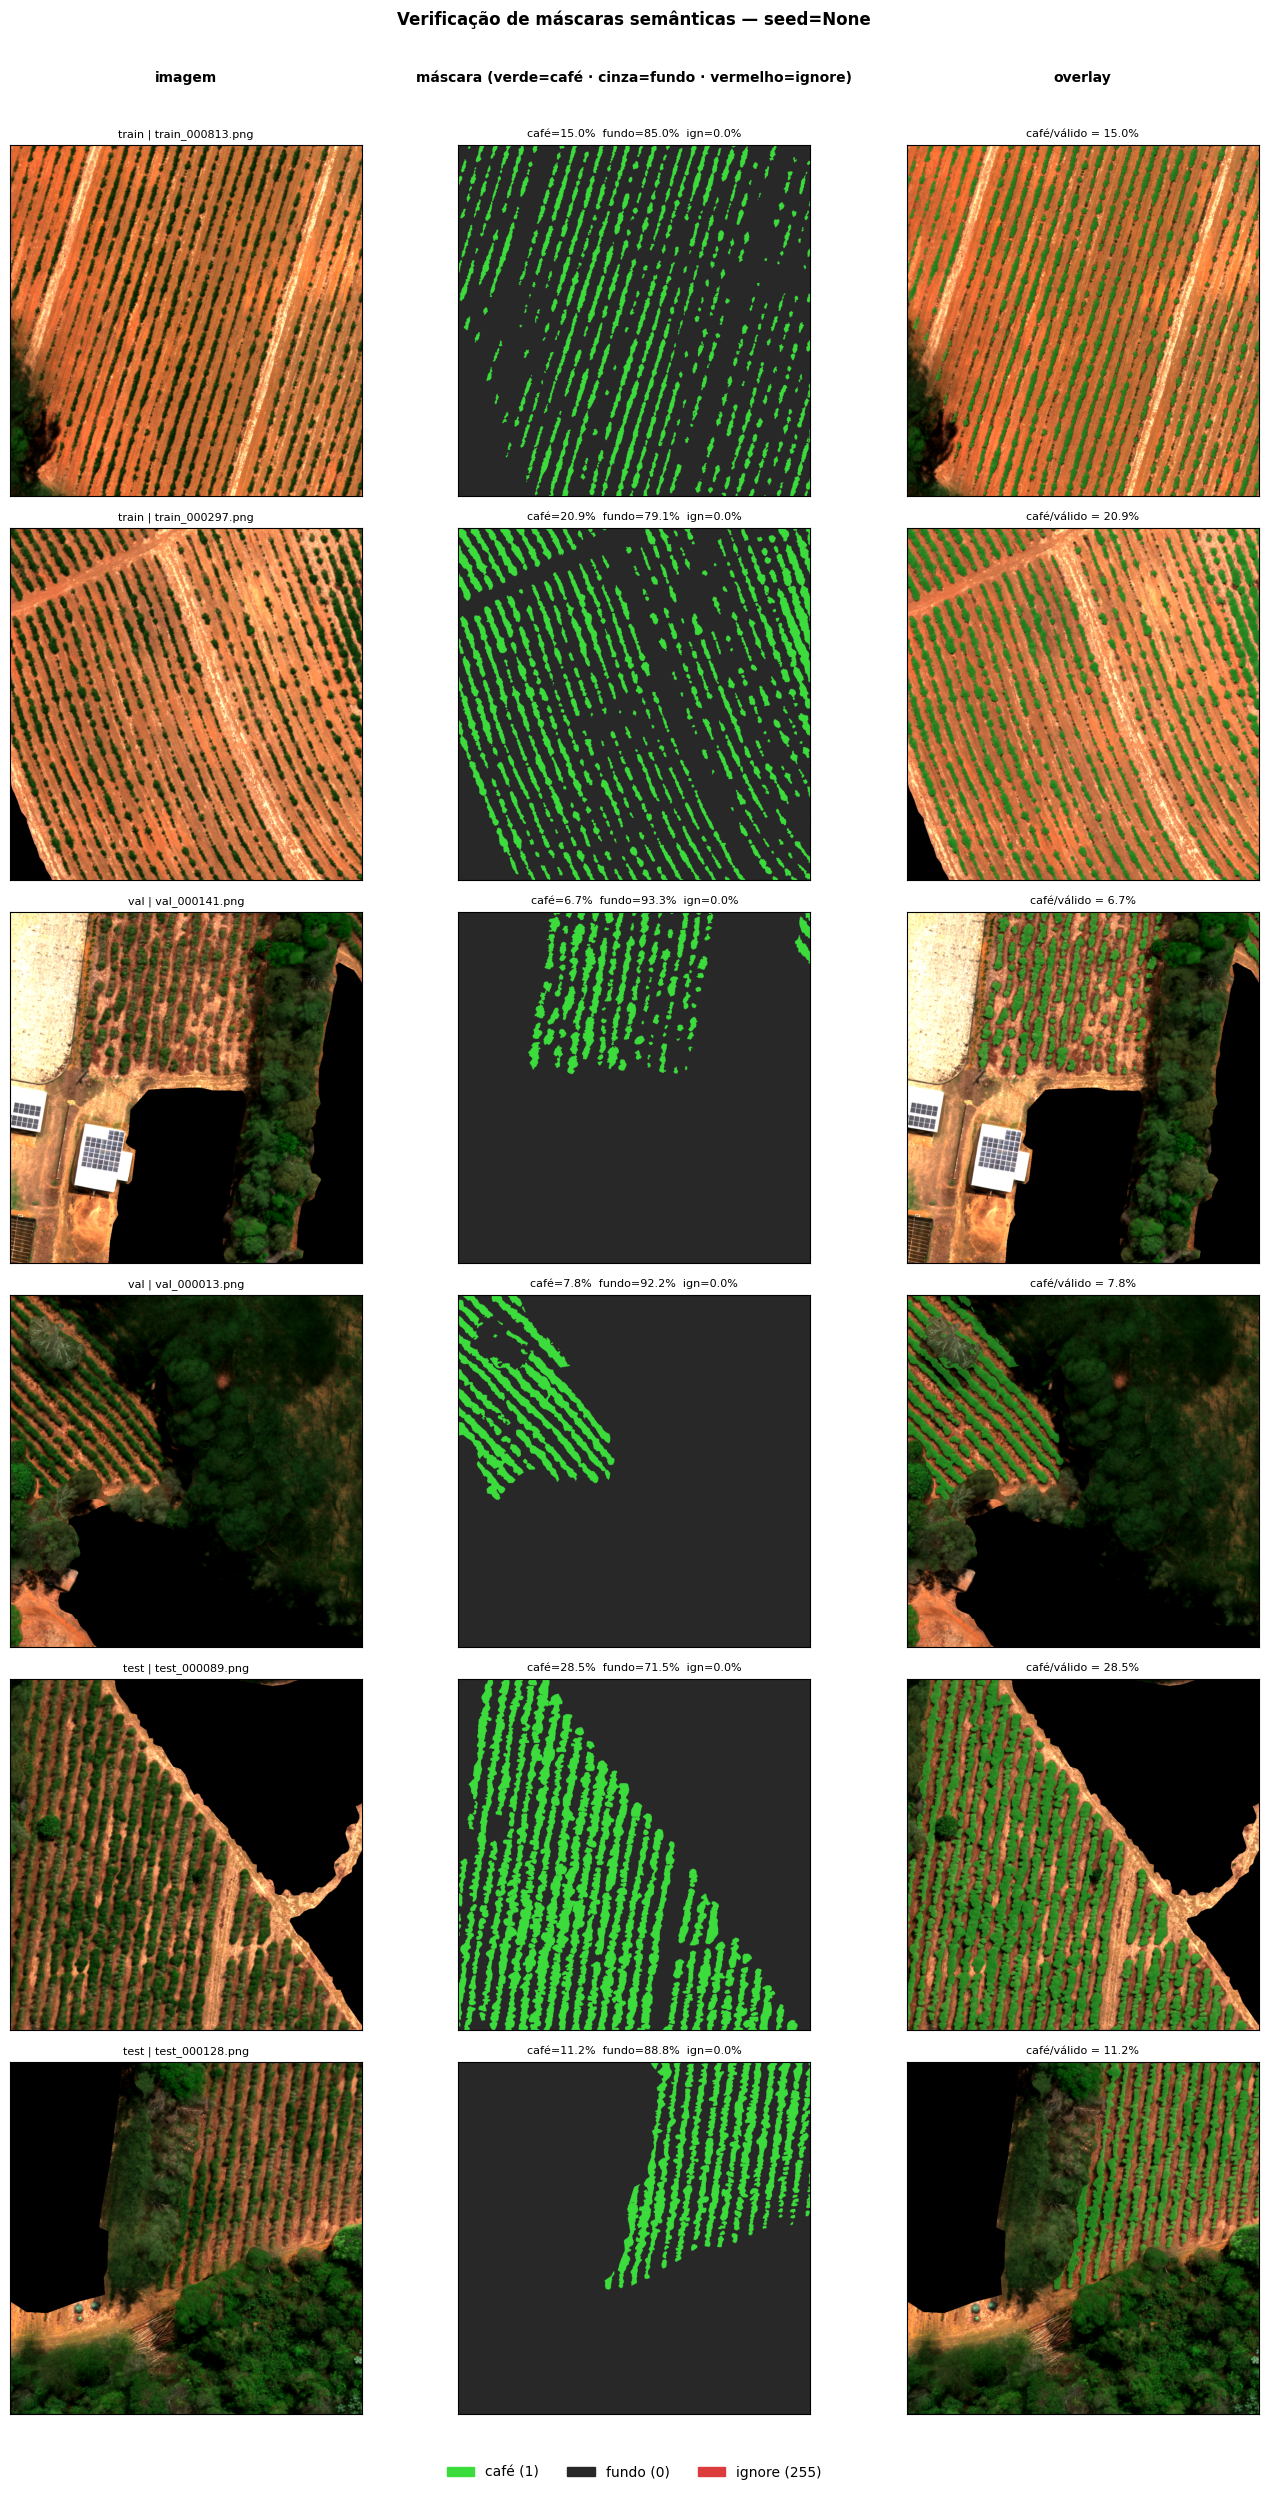

In [ ]:
if __name__ == "__main__":
    DATASET = "dataset_1024_final_cluster"
    plotar_amostras(
        dataset_root=DATASET,
        splits=("train", "val", "test"),
        n_por_split=2,
        seed=None,
        salvar_em=None,
    )